# SmartPriceAI
# Smartphone Price Category Prediction using Machine Learning
#
# Author:
# Harsheen Kaur
#
# GitHub:
# https://github.com/Harsheen-Kaur-Projects
#
# Copyright © 2026 Harsheen Kaur
#
# Licensed under the MIT License.

**A. Data Preparation**

1. Load dataset and display first 5 records

In [ ]:
import pandas as pd
from google.colab import files
files.upload()
df = pd.read_csv("SmartphoneSpecificationsDataset.csv")
df.head()

Saving SmartphoneSpecificationsDataset.csv to SmartphoneSpecificationsDataset.csv


,model,price,rating,os,sim_type,network_type,VoLTE,NFC,ir_blaster,chipset,...,resolution,refresh_rate_hz,display_type,rear_camera_mp_list,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb
0,oneplus 11 5g,54999,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,1440x3216,120.0,Punch Hole,"[50, 48, 32]",3,50.0,16.0,1,NaN,NaN
1,oneplus nord ce 2 lite 5g,19989,81.0,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,1080x2412,120.0,Punch Hole,"[64, 2, 2]",3,64.0,16.0,1,Hybrid,1024.0
2,samsung galaxy a14 5g,16499,75.0,Android v13,Dual,5g,True,False,False,Exynos 1330,...,1080x2408,90.0,Water Drop Notch,"[50, 2, 2]",3,50.0,13.0,1,Dedicated,1024.0
3,motorola moto g62 5g,14999,81.0,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,1080x2400,120.0,Punch Hole,"[50, 8, 2]",3,50.0,16.0,1,Hybrid,1024.0
4,realme 10 pro plus,24999,82.0,Android v13,Dual,5g,True,False,False,Dimensity 1080,...,1080x2412,120.0,Punch Hole,"[108, 8, 2]",3,108.0,16.0,1,NaN,NaN


2. Total rows and columns

In [ ]:
df.shape

(968, 27)

3. Column names and data types

In [ ]:
df.dtypes

,0
model,object
price,int64
rating,float64
os,object
sim_type,object
network_type,object
VoLTE,bool
NFC,bool
ir_blaster,bool
chipset,object


4. Check missing values

In [ ]:
df.isnull().sum()

,0
model,0
price,0
rating,0
os,26
sim_type,0
network_type,0
VoLTE,0
NFC,0
ir_blaster,0
chipset,0


5. Handle missing values

In [ ]:
df['fast_charge_w'] = df['fast_charge_w'].fillna(df['fast_charge_w'].median())
df['refresh_rate_hz'] = df['refresh_rate_hz'].fillna(df['refresh_rate_hz'].median())

In [ ]:
num_cols = df.select_dtypes(include=['number']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

6. Rename columns to snake_case

In [ ]:
df.columns = (
    df.columns
      .str.lower()
      .str.strip()
      .str.replace(" ", "_", regex=False)
)

7. Convert boolean columns

In [ ]:
df[['volte','nfc','ir_blaster']] = df[['volte','nfc','ir_blaster']].astype(bool)

8. Convert numeric columns

In [ ]:
cols = [
    'price',
    'rating',
    'ram_gb',
    'storage_gb',
    'battery_mah',
    'refresh_rate_hz',
    'fast_charge_w',
    'rear_camera_max_mp'
]

df[cols] = df[cols].apply(pd.to_numeric)

9. Extract screen width and height

In [ ]:
df['resolution'] = df['resolution'].fillna('0x0')
df[['screen_width','screen_height']] = df['resolution'].str.split('x', expand=True).astype(int)

In [ ]:
df["total_pixels"] = (
    df["screen_width"] *
    df["screen_height"]
)

10. Create price_category

In [ ]:
def price_cat(p):
    if p < 20000:
        return "Budget"
    elif p <= 40000:
        return "Mid-range"
    else:
        return "Premium"
df['price_category'] = df['price'].apply(price_cat)

/tmp/ipykernel_616/1404025486.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


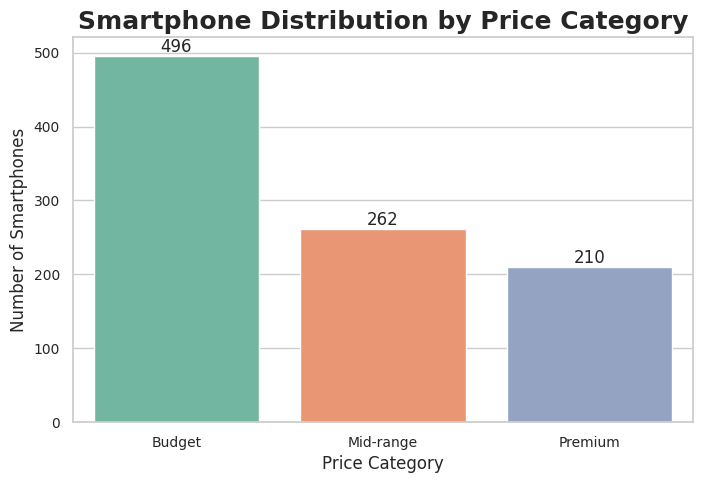

In [ ]:
plt.figure(figsize=(8,5))
category_count = df["price_category"].value_counts()
sns.barplot(
    x=category_count.index,
    y=category_count.values,
    palette="Set2"
)
plt.title(
    "Smartphone Distribution by Price Category",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel(
    "Price Category"
)
plt.ylabel(
    "Number of Smartphones"
)
for i,v in enumerate(category_count.values):
    plt.text(
        i,
        v+5,
        str(v),
        ha="center",
        fontsize=12
    )
plt.show()

**B. Filtering**

11. Phones below ₹20,000

In [ ]:
df[df['price'] < 20000]

,model,price,rating,os,sim_type,network_type,volte,nfc,ir_blaster,chipset,...,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,screen_width,screen_height,total_pixels,price_category
1,oneplus nord ce 2 lite 5g,19989,81.0,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,3,64.0,16.0,1,Hybrid,1024.0,1080,2412,2604960,Budget
2,samsung galaxy a14 5g,16499,75.0,Android v13,Dual,5g,True,False,False,Exynos 1330,...,3,50.0,13.0,1,Dedicated,1024.0,1080,2408,2600640,Budget
3,motorola moto g62 5g,14999,81.0,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,3,50.0,16.0,1,Hybrid,1024.0,1080,2400,2592000,Budget
5,samsung galaxy f23 5g,16999,80.0,Android v12,Dual,5g,True,True,False,Snapdragon 750G,...,3,50.0,8.0,1,Dedicated,1024.0,1080,2408,2600640,Budget
10,realme 10 pro,18999,82.0,Android v13,Dual,5g,True,False,False,Snapdragon 695,...,2,108.0,16.0,1,Dedicated,1024.0,1080,2400,2592000,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
953,ikall z18,6799,61.0,Android v10.0,Dual,4g,True,False,False,Quad Core,...,1,20.0,13.0,1,Hybrid,64.0,720,1560,1123200,Budget
958,realme narzo 50i prime,8720,64.0,Android v11,Dual,4g,True,False,False,Tiger T612,...,1,8.0,5.0,1,Dedicated,1024.0,720,1600,1152000,Budget
960,itel a23s,4787,80.0,Android v11,Dual,4g,False,False,False,Spreadtrum SC9832E,...,0,50.0,16.0,1,Dedicated,1024.0,854,480,409920,Budget
964,honor x8 5g,14990,75.0,Android v11,Dual,5g,True,False,False,Snapdragon 480+,...,2,48.0,8.0,1,Dedicated,1024.0,720,1600,1152000,Budget


12. Rating greater than 85

In [ ]:
df[df['rating'] > 85]

,model,price,rating,os,sim_type,network_type,volte,nfc,ir_blaster,chipset,...,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,screen_width,screen_height,total_pixels,price_category
0,oneplus 11 5g,54999,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,16.0,1,NaN,1024.0,1440,3216,4631040,Premium
7,xiaomi redmi note 12 pro plus,29999,86.0,Android v12,Dual,5g,True,False,True,Dimensity 1080,...,3,200.0,16.0,1,NaN,1024.0,1080,2400,2592000,Mid-range
17,oppo reno 9 pro plus,45999,86.0,Android v13,Dual,5g,True,True,False,Snapdragon 8+ Gen1,...,3,50.0,32.0,1,Dedicated,1024.0,1080,2412,2604960,Premium
18,oneplus 10r 5g,32999,86.0,Android v12,Dual,5g,True,True,False,Dimensity 8100 Max,...,3,50.0,16.0,1,Dedicated,1024.0,1080,2412,2604960,Mid-range
24,vivo v26 pro,42990,87.0,Android v13,Dual,5g,True,True,False,Dimensity 9000 Plus,...,3,64.0,32.0,1,Dedicated,1024.0,1080,2400,2592000,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,sharp aquos r5g,59990,88.0,Android v10,Dual,4g,True,True,False,Snapdragon 865,...,3,48.0,16.0,1,Hybrid,1024.0,1440,3168,4561920,Premium
955,xiaomi 14,54999,89.0,Android v13,Dual,5g,True,True,True,Snapdragon 8 Gen2,...,3,50.0,32.0,1,Dedicated,1024.0,1440,3200,4608000,Premium
956,motorola thinkphone,49990,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8+ Gen1,...,4,50.0,32.0,1,Dedicated,1024.0,1080,2400,2592000,Premium
957,xiaomi civi 3,32990,86.0,Android v13,Dual,5g,True,True,True,Dimensity 8200,...,4,64.0,32.0,1,Dedicated,1024.0,1080,2400,2592000,Mid-range


13. Devices supporting 5G & VoLTE

In [ ]:
df[(df['network_type']=='5g') & (df['volte']==True)]

,model,price,rating,os,sim_type,network_type,volte,nfc,ir_blaster,chipset,...,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,screen_width,screen_height,total_pixels,price_category
0,oneplus 11 5g,54999,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,16.0,1,NaN,1024.0,1440,3216,4631040,Premium
1,oneplus nord ce 2 lite 5g,19989,81.0,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,3,64.0,16.0,1,Hybrid,1024.0,1080,2412,2604960,Budget
2,samsung galaxy a14 5g,16499,75.0,Android v13,Dual,5g,True,False,False,Exynos 1330,...,3,50.0,13.0,1,Dedicated,1024.0,1080,2408,2600640,Budget
3,motorola moto g62 5g,14999,81.0,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,3,50.0,16.0,1,Hybrid,1024.0,1080,2400,2592000,Budget
4,realme 10 pro plus,24999,82.0,Android v13,Dual,5g,True,False,False,Dimensity 1080,...,3,108.0,16.0,1,NaN,1024.0,1080,2412,2604960,Mid-range
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,motorola moto edge s30 pro,34990,83.0,Android v12,Dual,5g,True,False,False,Snapdragon 8 Gen1,...,3,64.0,16.0,1,Dedicated,1024.0,1080,2460,2656800,Mid-range
964,honor x8 5g,14990,75.0,Android v11,Dual,5g,True,False,False,Snapdragon 480+,...,2,48.0,8.0,1,Dedicated,1024.0,720,1600,1152000,Budget
965,poco x4 gt 5g,28990,85.0,Android v12,Dual,5g,True,True,True,Dimensity 8100,...,3,64.0,16.0,1,NaN,1024.0,1080,2460,2656800,Mid-range
966,motorola moto g91 5g,19990,80.0,Android v12,Dual,5g,True,True,False,Snapdragon 695,...,3,108.0,32.0,1,Dedicated,1024.0,1080,2400,2592000,Budget


14. Android v13 phones

In [ ]:
df[df['os']=='Android v13']

,model,price,rating,os,sim_type,network_type,volte,nfc,ir_blaster,chipset,...,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,screen_width,screen_height,total_pixels,price_category
0,oneplus 11 5g,54999,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,16.0,1,NaN,1024.0,1440,3216,4631040,Premium
2,samsung galaxy a14 5g,16499,75.0,Android v13,Dual,5g,True,False,False,Exynos 1330,...,3,50.0,13.0,1,Dedicated,1024.0,1080,2408,2600640,Budget
4,realme 10 pro plus,24999,82.0,Android v13,Dual,5g,True,False,False,Dimensity 1080,...,3,108.0,16.0,1,NaN,1024.0,1080,2412,2604960,Mid-range
10,realme 10 pro,18999,82.0,Android v13,Dual,5g,True,False,False,Snapdragon 695,...,2,108.0,16.0,1,Dedicated,1024.0,1080,2400,2592000,Budget
14,samsung galaxy s23 ultra 5g,114990,80.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,1,200.0,12.0,1,NaN,1024.0,1440,3088,4446720,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,tecno camon 20 premier,20999,79.0,Android v13,Dual,5g,True,True,False,Dimensity 700 5G,...,3,50.0,16.0,1,Dedicated,1024.0,1080,2460,2656800,Mid-range
955,xiaomi 14,54999,89.0,Android v13,Dual,5g,True,True,True,Snapdragon 8 Gen2,...,3,50.0,32.0,1,Dedicated,1024.0,1440,3200,4608000,Premium
956,motorola thinkphone,49990,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8+ Gen1,...,4,50.0,32.0,1,Dedicated,1024.0,1080,2400,2592000,Premium
957,xiaomi civi 3,32990,86.0,Android v13,Dual,5g,True,True,True,Dimensity 8200,...,4,64.0,32.0,1,Dedicated,1024.0,1080,2400,2592000,Mid-range


15. RAM ≥ 8 GB

In [ ]:
df[df['ram_gb'] >= 8]

,model,price,rating,os,sim_type,network_type,volte,nfc,ir_blaster,chipset,...,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,screen_width,screen_height,total_pixels,price_category
0,oneplus 11 5g,54999,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,16.0,1,NaN,1024.0,1440,3216,4631040,Premium
7,xiaomi redmi note 12 pro plus,29999,86.0,Android v12,Dual,5g,True,False,True,Dimensity 1080,...,3,200.0,16.0,1,NaN,1024.0,1080,2400,2592000,Mid-range
8,nothing phone 1,26749,85.0,Android v12,Dual,5g,True,True,False,Snapdragon 778G Plus,...,2,50.0,16.0,1,Dedicated,1024.0,1080,2400,2592000,Mid-range
9,oneplus nord 2t 5g,28999,84.0,Android v12,Dual,5g,True,True,False,Dimensity 1300,...,3,50.0,32.0,1,Dedicated,1024.0,1080,2400,2592000,Mid-range
11,oppo a78,18999,79.0,Android v12,Dual,5g,True,True,False,Dimensity 700 5G,...,2,50.0,8.0,1,Dedicated,1024.0,720,1612,1160640,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
961,google pixel 8 pro,70990,80.0,Android v13,Dual,5g,True,True,False,Google Tensor 3,...,3,50.0,12.0,1,Dedicated,1024.0,1440,3120,4492800,Premium
962,vivo x fold 2,119990,80.0,NaN,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,32.0,1,Dedicated,1024.0,1916,2160,4138560,Premium
963,motorola moto edge s30 pro,34990,83.0,Android v12,Dual,5g,True,False,False,Snapdragon 8 Gen1,...,3,64.0,16.0,1,Dedicated,1024.0,1080,2460,2656800,Mid-range
965,poco x4 gt 5g,28990,85.0,Android v12,Dual,5g,True,True,True,Dimensity 8100,...,3,64.0,16.0,1,NaN,1024.0,1080,2460,2656800,Mid-range


16. Battery ≥ 5000 mAh

In [ ]:
df[df['battery_mah'] >= 5000]

,model,price,rating,os,sim_type,network_type,volte,nfc,ir_blaster,chipset,...,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,screen_width,screen_height,total_pixels,price_category
0,oneplus 11 5g,54999,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,16.0,1,NaN,1024.0,1440,3216,4631040,Premium
1,oneplus nord ce 2 lite 5g,19989,81.0,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,3,64.0,16.0,1,Hybrid,1024.0,1080,2412,2604960,Budget
2,samsung galaxy a14 5g,16499,75.0,Android v13,Dual,5g,True,False,False,Exynos 1330,...,3,50.0,13.0,1,Dedicated,1024.0,1080,2408,2600640,Budget
3,motorola moto g62 5g,14999,81.0,Android v12,Dual,5g,True,False,False,Snapdragon 695,...,3,50.0,16.0,1,Hybrid,1024.0,1080,2400,2592000,Budget
4,realme 10 pro plus,24999,82.0,Android v13,Dual,5g,True,False,False,Dimensity 1080,...,3,108.0,16.0,1,NaN,1024.0,1080,2412,2604960,Mid-range
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,motorola moto edge s30 pro,34990,83.0,Android v12,Dual,5g,True,False,False,Snapdragon 8 Gen1,...,3,64.0,16.0,1,Dedicated,1024.0,1080,2460,2656800,Mid-range
964,honor x8 5g,14990,75.0,Android v11,Dual,5g,True,False,False,Snapdragon 480+,...,2,48.0,8.0,1,Dedicated,1024.0,720,1600,1152000,Budget
965,poco x4 gt 5g,28990,85.0,Android v12,Dual,5g,True,True,True,Dimensity 8100,...,3,64.0,16.0,1,NaN,1024.0,1080,2460,2656800,Mid-range
966,motorola moto g91 5g,19990,80.0,Android v12,Dual,5g,True,True,False,Snapdragon 695,...,3,108.0,32.0,1,Dedicated,1024.0,1080,2400,2592000,Budget


17. NFC-supported phones

In [ ]:
df[df['nfc']==True]

,model,price,rating,os,sim_type,network_type,volte,nfc,ir_blaster,chipset,...,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,screen_width,screen_height,total_pixels,price_category
0,oneplus 11 5g,54999,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,16.0,1,NaN,1024.0,1440,3216,4631040,Premium
5,samsung galaxy f23 5g,16999,80.0,Android v12,Dual,5g,True,True,False,Snapdragon 750G,...,3,50.0,8.0,1,Dedicated,1024.0,1080,2408,2600640,Budget
6,apple iphone 14,65999,81.0,iOS v16,Dual,5g,True,True,False,Bionic A15,...,2,12.0,12.0,1,NaN,1024.0,1170,2532,2962440,Premium
8,nothing phone 1,26749,85.0,Android v12,Dual,5g,True,True,False,Snapdragon 778G Plus,...,2,50.0,16.0,1,Dedicated,1024.0,1080,2400,2592000,Mid-range
9,oneplus nord 2t 5g,28999,84.0,Android v12,Dual,5g,True,True,False,Dimensity 1300,...,3,50.0,32.0,1,Dedicated,1024.0,1080,2400,2592000,Mid-range
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959,oppo find x6,69990,89.0,Android v12,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,32.0,1,Dedicated,1024.0,1080,2400,2592000,Premium
961,google pixel 8 pro,70990,80.0,Android v13,Dual,5g,True,True,False,Google Tensor 3,...,3,50.0,12.0,1,Dedicated,1024.0,1440,3120,4492800,Premium
962,vivo x fold 2,119990,80.0,NaN,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,32.0,1,Dedicated,1024.0,1916,2160,4138560,Premium
965,poco x4 gt 5g,28990,85.0,Android v12,Dual,5g,True,True,True,Dimensity 8100,...,3,64.0,16.0,1,NaN,1024.0,1080,2460,2656800,Mid-range


18. Fast charging ≥ 100W

In [ ]:
df[df['fast_charge_w'] >= 100]

,model,price,rating,os,sim_type,network_type,volte,nfc,ir_blaster,chipset,...,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,screen_width,screen_height,total_pixels,price_category
0,oneplus 11 5g,54999,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,16.0,1,NaN,1024.0,1440,3216,4631040,Premium
7,xiaomi redmi note 12 pro plus,29999,86.0,Android v12,Dual,5g,True,False,True,Dimensity 1080,...,3,200.0,16.0,1,NaN,1024.0,1080,2400,2592000,Mid-range
20,oneplus 11r,39999,85.0,Android v13,Dual,5g,True,True,False,Snapdragon 8+ Gen1,...,3,50.0,16.0,1,Dedicated,1024.0,1080,2412,2604960,Mid-range
24,vivo v26 pro,42990,87.0,Android v13,Dual,5g,True,True,False,Dimensity 9000 Plus,...,3,64.0,32.0,1,Dedicated,1024.0,1080,2400,2592000,Premium
29,oneplus 11 pro,69999,80.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,16.0,1,Dedicated,1024.0,1440,3216,4631040,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,oneplus ace pro,47990,86.0,Android v12,Dual,5g,True,True,False,Snapdragon 8+ Gen1,...,3,50.0,16.0,1,Dedicated,1024.0,1080,2412,2604960,Premium
898,realme gt 2 explorer master edition,40990,86.0,Android v12,Dual,5g,True,True,False,Snapdragon 8+ Gen1,...,2,50.0,16.0,1,Dedicated,1024.0,1080,2412,2604960,Premium
902,poco f5 gt 5g,42999,86.0,Android v12,Dual,5g,True,True,True,Dimensity 1300,...,3,64.0,20.0,1,NaN,1024.0,1080,2412,2604960,Premium
910,xiaomi 11i hypercharge 5g,26999,86.0,Android v11,Dual,5g,True,False,True,Dimensity 920 5G,...,3,108.0,16.0,1,Hybrid,1024.0,2400,1080,2592000,Mid-range


**C. Sorting**

19. Sort by price (descending)

In [ ]:
df.sort_values('price', ascending=False)

,model,price,rating,os,sim_type,network_type,volte,nfc,ir_blaster,chipset,...,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,screen_width,screen_height,total_pixels,price_category
428,vertu signature touch,650000,62.0,Android v4.4.2 (KitKat),Single,4g,False,True,False,Snapdragon 801,...,1,13.0,16.0,1,NaN,1024.0,1080,1920,2073600,Premium
880,xiaomi redmi k20 pro signature edition,480000,88.0,Android v9.0 (Pie),Dual,4g,True,True,False,Snapdragon 855,...,3,48.0,20.0,1,NaN,1024.0,1080,2340,2527200,Premium
477,huawei mate 50 rs porsche design,239999,81.0,Hongmeng OS v3.0,Dual,4g,True,True,True,Snapdragon 8+ Gen1,...,3,50.0,13.0,1,Hybrid,256.0,1212,2616,3170592,Premium
940,huawei mate 30 rs porsche design,214990,80.0,Android v10,Dual,5g,True,True,True,Kirin 990,...,1,40.0,32.0,1,Hybrid,256.0,1176,2400,2822400,Premium
459,xiaomi redmi mix alpha,199990,80.0,Android v10,Dual,5g,True,False,False,Snapdragon 855+,...,2,108.0,16.0,1,NaN,1024.0,2088,2250,4698000,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960,itel a23s,4787,80.0,Android v11,Dual,4g,False,False,False,Spreadtrum SC9832E,...,0,50.0,16.0,1,Dedicated,1024.0,854,480,409920,Budget
350,jio jiophone next,4649,80.0,Android v11,Dual,4g,True,False,False,Qualcomm 215,...,1,13.0,8.0,1,Dedicated,512.0,720,1440,1036800,Budget
143,jio phone 3,4499,80.0,Android v8.1 (Oreo),Dual,4g,True,False,False,Quad Core,...,1,5.0,2.0,1,Dedicated,128.0,720,1280,921600,Budget
189,realme c2s,3499,63.0,Android v9.0 (Pie),Dual,4g,True,False,False,Helio P22,...,2,13.0,5.0,1,Dedicated,128.0,720,1560,1123200,Budget


20. Sort by rating (ascending)

In [ ]:
df.sort_values('rating')

,model,price,rating,os,sim_type,network_type,volte,nfc,ir_blaster,chipset,...,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,screen_width,screen_height,total_pixels,price_category
650,infinix smart 6,7320,60.0,Android v11,Dual,4g,True,False,False,Helio A22,...,1,8.0,5.0,1,Dedicated,512.0,720,1600,1152000,Budget
760,micromax in 2c,5999,60.0,Android v11,Dual,4g,True,False,False,Tiger T610,...,1,8.0,5.0,1,Dedicated,256.0,720,1600,1152000,Budget
893,tcl ion x,8990,60.0,Android,Dual,4g,True,False,False,Helio G25,...,1,13.0,5.0,1,Hybrid,1024.0,720,1440,1036800,Budget
300,realme c30,6299,60.0,Android v11,Dual,4g,True,False,False,Tiger T612,...,1,8.0,5.0,1,Dedicated,1024.0,720,1600,1152000,Budget
801,samsung galaxy m14,14999,60.0,Android v13,Dual,4g,True,False,False,Exynos 1330,...,3,48.0,8.0,1,Dedicated,512.0,720,1600,1152000,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
614,sony xperia 1 ii,69999,89.0,Android v10,Dual,5g,True,True,False,Snapdragon 865,...,1,12.0,8.0,1,Hybrid,1024.0,1644,3840,6312960,Premium
66,oneplus 10 pro 5g,60999,89.0,Android v12,Dual,5g,True,True,False,Snapdragon 8 Gen1,...,3,50.0,32.0,1,Dedicated,1024.0,1440,3216,4631040,Premium
58,samsung galaxy s23 plus,84990,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,12.0,1,Dedicated,1024.0,1080,2340,2527200,Premium
663,samsung galaxy note 10 plus 5g,92999,89.0,Android v9.0 (Pie),Dual,5g,True,True,True,Exynos 9825,...,1,12.0,10.0,1,Hybrid,512.0,1440,3040,4377600,Premium


21. Sort by battery capacity

In [ ]:
df.sort_values('battery_mah', ascending=False)

,model,price,rating,os,sim_type,network_type,volte,nfc,ir_blaster,chipset,...,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,screen_width,screen_height,total_pixels,price_category
838,doogee v max,45999,88.0,Android v12,Dual,5g,True,False,False,Dimensity 1080,...,3,108.0,32.0,1,Hybrid,2048.0,1080,2408,2600640,Premium
391,oukitel wp19,29990,84.0,Android v12,Dual,4g,True,True,False,Helio G95,...,3,64.0,16.0,1,Dedicated,1024.0,1080,2400,2592000,Mid-range
599,oukitel wp21,22990,82.0,NaN,Dual,4g,True,False,False,Helio G99,...,0,50.0,16.0,1,Hybrid,1024.0,1080,2400,2592000,Mid-range
954,oukitel wp9,25899,72.0,Android v10,Dual,4g,False,True,False,Helio P60,...,3,16.0,8.0,1,Dedicated,1024.0,720,1520,1094400,Mid-range
862,tecno pova 2,10999,74.0,Android v11,Dual,4g,True,False,False,Helio G85,...,1,48.0,8.0,1,Dedicated,256.0,1080,2460,2656800,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
814,cat s22 flip,14999,80.0,NaN,Single,4g,True,False,False,Qualcomm 215,...,0,50.0,16.0,1,Dedicated,128.0,480,640,307200,Budget
397,jio jiophone 2,2999,80.0,KAI OS,Dual,4g,True,False,False,Dual Core,...,1,2.0,16.0,1,Dedicated,128.0,320,240,76800,Budget
473,vivo y25,7499,80.0,Android v5.1 (Lollipop),Dual,4g,False,False,False,Helio MT6580,...,1,5.0,2.0,1,Dedicated,128.0,480,854,409920,Budget
638,apple iphone se 2020,39900,63.0,iOS v13,Dual,4g,True,True,False,A13 Bionic,...,1,12.0,7.0,1,Dedicated,1024.0,750,1334,1000500,Mid-range


22. Sort by rear camera MP

In [ ]:
df.sort_values('rear_camera_max_mp', ascending=False)

,model,price,rating,os,sim_type,network_type,volte,nfc,ir_blaster,chipset,...,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,screen_width,screen_height,total_pixels,price_category
294,motorola edge 30 ultra,59999,80.0,Android v12,Dual,5g,True,True,False,Snapdragon 8+ Gen1,...,3,200.0,60.0,1,Dedicated,1024.0,1080,2400,2592000,Premium
67,xiaomi redmi note 12 pro plus,32999,87.0,Android v12,Dual,5g,True,False,True,Dimensity 1080,...,3,200.0,16.0,1,NaN,1024.0,1080,2400,2592000,Mid-range
201,motorola edge 30 ultra,54999,80.0,Android v12,Dual,5g,True,True,False,Snapdragon 8+ Gen1,...,3,200.0,60.0,1,Dedicated,1024.0,1080,2400,2592000,Premium
239,xiaomi redmi note 12 explorer,24999,89.0,Android v12,Dual,5g,True,True,True,Dimensity 1080,...,3,200.0,16.0,1,Dedicated,512.0,1080,2400,2592000,Mid-range
915,nokia x60 5g,39990,87.0,Harmony v2.0,Dual,5g,True,False,False,Snapdragon 870,...,1,200.0,16.0,1,Dedicated,1024.0,1080,2400,2592000,Mid-range
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
712,tecno pop 5 go,6999,80.0,Android v11,Dual,4g,False,False,False,Spreadtrum SC7731,...,2,5.0,5.0,1,Dedicated,1024.0,720,1520,1094400,Budget
93,vivo x90 pro plus 5g,73999,80.0,Android v13,Dual,5g,True,True,True,Snapdragon 8 Gen2,...,1,3.0,32.0,1,Dedicated,1024.0,1440,3200,4608000,Premium
397,jio jiophone 2,2999,80.0,KAI OS,Dual,4g,True,False,False,Dual Core,...,1,2.0,16.0,1,Dedicated,128.0,320,240,76800,Budget
500,google pixel 2 xl,15990,69.0,Android v8.0 (Oreo),Single,4g,True,True,False,Snapdragon 835,...,1,2.0,8.0,1,NaN,1024.0,1440,2880,4147200,Budget


23. Top 5 highest refresh rate phones

In [ ]:
df.sort_values('refresh_rate_hz', ascending=False).head(5)

,model,price,rating,os,sim_type,network_type,volte,nfc,ir_blaster,chipset,...,rear_camera_count,rear_camera_max_mp,front_camera_mp,memory_card_supported,memory_card_type,memory_card_max_gb,screen_width,screen_height,total_pixels,price_category
783,leitz phone 2,124990,89.0,Android v12,Dual,5g,True,True,False,Snapdragon 8 Gen1,...,2,9.0,16.0,1,Dedicated,1024.0,1260,2730,3439800,Premium
182,motorola moto x40,39999,89.0,Android v13,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,60.0,1,Dedicated,1024.0,1080,2400,2592000,Mid-range
913,nubia red magic 6s 5g,44999,84.0,Android v11,Dual,5g,True,True,False,Snapdragon 888+,...,3,64.0,8.0,1,Dedicated,1024.0,1080,2400,2592000,Premium
698,asus rog phone 6d ultimate,107990,80.0,NaN,Dual,5g,True,True,False,Dimensity 9000 Plus,...,0,50.0,16.0,1,NaN,1024.0,1080,2448,2643840,Premium
571,motorola edge 40 pro 5g,59990,89.0,Android v12,Dual,5g,True,True,False,Snapdragon 8 Gen2,...,3,50.0,60.0,1,Dedicated,1024.0,1080,2460,2656800,Premium


**D. Aggregation**

24. Average price

In [ ]:
df['price'].mean()

np.float64(32745.954545454544)

25. Max & Min rating

In [ ]:
df['rating'].max(), df['rating'].min()

(89.0, 60.0)

26. Average RAM & storage

In [ ]:
df[['ram_gb','storage_gb']].mean()

,0
ram_gb,7.641529
storage_gb,7.641529


27. Average battery capacity

In [ ]:
df['battery_mah'].mean()

np.float64(4821.981404958678)

28. Count of NFC phones

In [ ]:
df['nfc'].sum()

np.int64(391)

**E. Grouping**

29. Group by OS – avg price

In [ ]:
df.groupby('os')['price'].mean()

,price
os,
0,6899.000000
Android,8990.000000
Android v10,31764.424242
Android v10.0,31102.695652
Android v11,18219.666667
Android v11.0,7145.500000
Android v12,27468.142105
Android v12.1,60999.000000
Android v13,39703.666667


30. Group by brand

In [ ]:
df.groupby(df['model'].str.split().str[0]).size()

,0
model,
apple,46
asus,7
blackview,1
blu,1
cat,1
cola,1
doogee,2
duoqin,1
gionee,3


31. Group by price_category – avg rating

In [ ]:
if "price_category" not in df.columns:
    df["price_category"] = df["price"].apply(price_cat)

In [ ]:
df.groupby('price_category')['rating'].mean()

,rating
price_category,
Budget,74.584677
Mid-range,82.641221
Premium,82.766667


32. Group by network type – avg battery

In [ ]:
df.groupby('network_type')['battery_mah'].mean()

,battery_mah
network_type,
4g,4838.442080
5g,4809.205505


33. Group by RAM – avg price

In [ ]:
df.groupby('ram_gb')['price'].mean()

,price
ram_gb,
1,6244.500000
2,27876.709677
3,10886.019608
4,16026.226415
6,29582.582609
8,38443.961652
12,72910.872093
16,62330.333333
18,82994.500000


34. Group by refresh rate – avg rating

In [ ]:
df.groupby('refresh_rate_hz')['rating'].mean()

,rating
refresh_rate_hz,
90.0,78.004608
120.0,78.293030
144.0,84.131579
165.0,86.000000
240.0,89.000000


35. Price category with highest avg camera MP

In [ ]:
df.groupby('price_category')['rear_camera_max_mp'].mean()

,rear_camera_max_mp
price_category,
Budget,41.727823
Mid-range,63.255725
Premium,56.342857


**MODEL BUILDING**

1. Define Problem & Goal

In [ ]:
# Problem Statement:
# To build a machine learning model that predicts the price category
# (Budget, Mid-range, Premium) of a smartphone based on its specifications.

2. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(
    style="whitegrid",
    context="notebook"
)
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

3. Load Dataset

4. Data Preparation & Feature Selection

In [ ]:
df["storage_ram_ratio"] = (
    df["storage_gb"] /
    df["ram_gb"]
)

df["fast_charge_ratio"] = (
    df["fast_charge_w"] /
    df["battery_mah"]
)

df["premium_display"] = (
    df["refresh_rate_hz"] >= 120
).astype(int)


df["battery_per_ram"] = (
    df["battery_mah"] /
    df["ram_gb"]
)


df["camera_battery_ratio"] = (
    df["rear_camera_max_mp"] /
    df["battery_mah"]
)


df["high_storage"] = (
    df["storage_gb"] >= 256
).astype(int)


df["high_ram"] = (
    df["ram_gb"] >= 12
).astype(int)


df["performance_score"] = (
    df["ram_gb"] *
    df["clock_ghz"]
)


df["camera_score"] = (
    df["rear_camera_count"] *
    df["rear_camera_max_mp"]
)


df["charging_power_score"] = (
    df["fast_charge_w"] /
    df["battery_mah"]
)


df["pixel_density"] = (
    df["total_pixels"] /
    (df["screen_size_in"].replace(0,1) ** 2)
)


df["battery_storage_ratio"] = (
    df["battery_mah"] /
    df["storage_gb"]
)


df["ram_clock_score"] = (
    df["ram_gb"] *
    df["clock_ghz"]
)


df["camera_per_sensor"] = (
    df["rear_camera_max_mp"] /
    df["rear_camera_count"].replace(0,1)
)

In [ ]:
features = [

    # Numeric
    "rating",
    "ram_gb",
    "storage_gb",
    "battery_mah",
    "fast_charge_w",
    "clock_ghz",
    "refresh_rate_hz",
    "rear_camera_max_mp",
    "rear_camera_count",
    "front_camera_mp",
    "screen_width",
    "screen_height",
    "total_pixels",
    "screen_size_in",

    # Engineered
    "storage_ram_ratio",
    "fast_charge_ratio",
    "premium_display",
    "battery_per_ram",
    "camera_battery_ratio",
    "high_storage",
    "high_ram",
    "performance_score",
    "camera_score",
    "charging_power_score",
    "pixel_density",
    "battery_storage_ratio",
    "ram_clock_score",
    "camera_per_sensor",

    # Categorical
    "os",
    "network_type",
    "sim_type",
    "volte",
    "nfc",
    "ir_blaster",
    "chipset",
    "core_type",
    "display_type",
    "memory_card_supported",
    "memory_card_type"
]

In [ ]:
print(df.columns.tolist())

['model', 'price', 'rating', 'os', 'sim_type', 'network_type', 'volte', 'nfc', 'ir_blaster', 'chipset', 'core_type', 'clock_ghz', 'ram_gb', 'storage_gb', 'battery_mah', 'fast_charge_w', 'screen_size_in', 'resolution', 'refresh_rate_hz', 'display_type', 'rear_camera_mp_list', 'rear_camera_count', 'rear_camera_max_mp', 'front_camera_mp', 'memory_card_supported', 'memory_card_type', 'memory_card_max_gb', 'screen_width', 'screen_height', 'total_pixels', 'price_category', 'storage_ram_ratio', 'fast_charge_ratio', 'premium_display', 'battery_per_ram', 'camera_battery_ratio', 'high_storage', 'high_ram', 'performance_score', 'camera_score', 'charging_power_score', 'pixel_density', 'battery_storage_ratio', 'ram_clock_score', 'camera_per_sensor']


5. Encode Target Variable

In [ ]:
X = df[features]
y = df["price_category"]

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

6. Feature Scaling

In [ ]:
X = pd.get_dummies(
    X,
    drop_first=True
)
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)
X = X.fillna(0)
X_processed = X

7. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.15,
    random_state=42,
    stratify=y_encoded
)

8. Model 1: Logistic Regression

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
    X_train
)
X_test_scaled = scaler.transform(
    X_test
)
logistic_model = LogisticRegression(
    max_iter=20000,
    C=1.5,
    solver="lbfgs",
    random_state=42
)
logistic_model.fit(
    X_train_scaled,
    y_train
)
y_pred_logistic = logistic_model.predict(
    X_test_scaled
)

9. Logistic Regression Evaluation

In [ ]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_logistic))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic, zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Logistic Regression Accuracy:
0.7602739726027398

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83        75
           1       0.57      0.69      0.63        39
           2       0.78      0.78      0.78        32

    accuracy                           0.76       146
   macro avg       0.75      0.75      0.75       146
weighted avg       0.78      0.76      0.77       146


Confusion Matrix:
[[59 14  2]
 [ 7 27  5]
 [ 1  6 25]]


10. Model 2: Decision Tree Classifier

In [ ]:
decision_tree_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=12,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42
)

decision_tree_model.fit(
    X_train,
    y_train
)

y_pred_tree = decision_tree_model.predict(
    X_test
)

11. Decision Tree Evaluation

In [ ]:
print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_tree))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree, zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree Accuracy:
0.773972602739726

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        75
           1       0.62      0.67      0.64        39
           2       0.77      0.75      0.76        32

    accuracy                           0.77       146
   macro avg       0.75      0.75      0.75       146
weighted avg       0.78      0.77      0.78       146


Confusion Matrix:
[[63 11  1]
 [ 7 26  6]
 [ 3  5 24]]


12. Model 3: Random Forest Classifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=25,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test
)

13. Random Forest Evaluation

In [ ]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy:
0.8287671232876712

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        75
           1       0.66      0.79      0.72        39
           2       0.92      0.72      0.81        32

    accuracy                           0.83       146
   macro avg       0.83      0.80      0.81       146
weighted avg       0.84      0.83      0.83       146


Confusion Matrix:
[[67  8  0]
 [ 6 31  2]
 [ 1  8 23]]


/tmp/ipykernel_616/3365258394.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


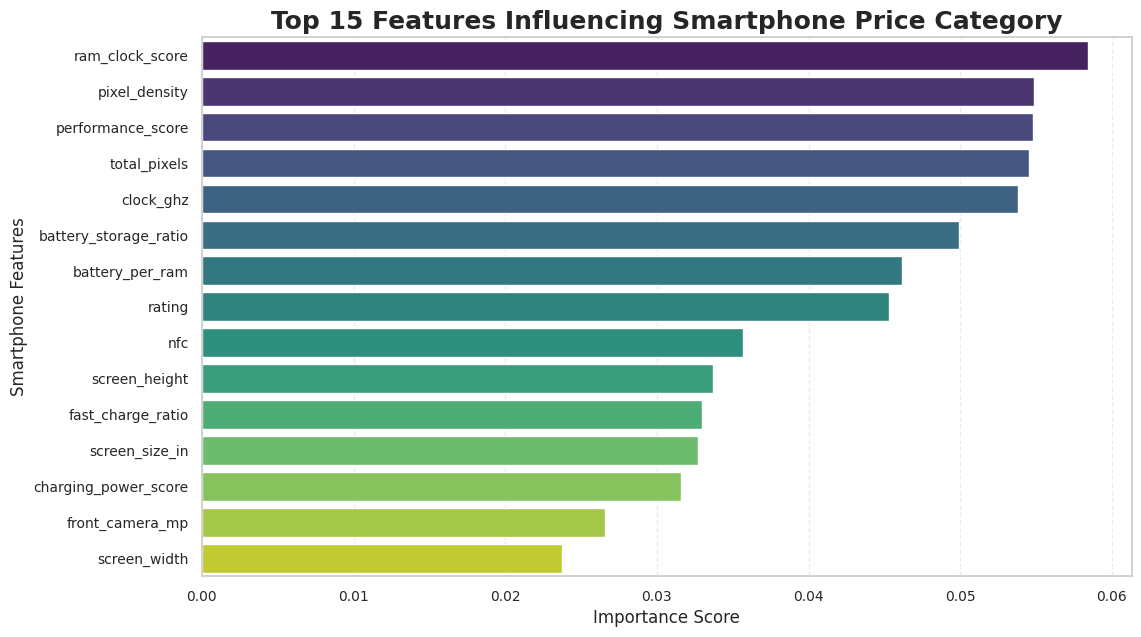

In [ ]:
importance_plot = pd.DataFrame({
    "Feature": X.columns,
    "Importance":
    rf_model.feature_importances_
})
importance_plot = importance_plot.sort_values(
    "Importance",
    ascending=False
).head(15)
plt.figure(figsize=(12,7))
sns.barplot(
    data=importance_plot,
    x="Importance",
    y="Feature",
    palette="viridis"
)
plt.title(
    "Top 15 Features Influencing Smartphone Price Category",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel(
    "Importance Score"
)
plt.ylabel(
    "Smartphone Features"
)
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)
plt.show()

In [ ]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_logistic))
print("\nDecision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_tree))
print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy:
0.7602739726027398

Decision Tree Accuracy:
0.773972602739726

Random Forest Accuracy:
0.8287671232876712


14. Model Comparison

                 Model  Accuracy
2        Random Forest  0.828767
1        Decision Tree  0.773973
0  Logistic Regression  0.760274


/tmp/ipykernel_616/726237931.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  accuracy_plot = sns.barplot(


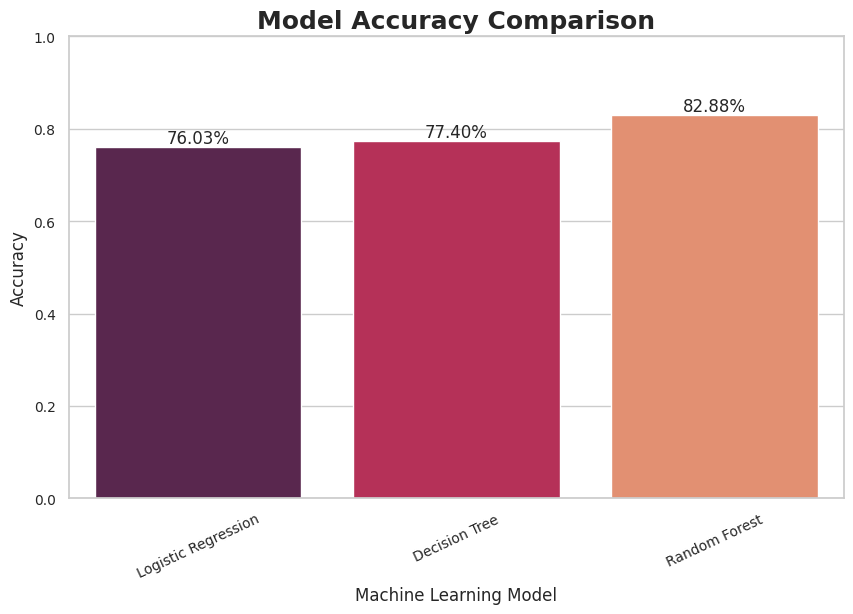

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ]
})
print(comparison.sort_values("Accuracy", ascending=False))
plt.figure(figsize=(10,6))
accuracy_plot = sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="rocket"
)
plt.title(
    "Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel(
    "Machine Learning Model"
)
plt.ylabel(
    "Accuracy"
)
plt.ylim(
    0,
    1
)
for bar in accuracy_plot.patches:
    accuracy_plot.annotate(
        f"{bar.get_height():.2%}",
        (
            bar.get_x()+bar.get_width()/2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=12
    )
plt.xticks(
    rotation=25
)
plt.show()

15. Hyperparameter Tuning (Decision Tree)

In [ ]:
param_dist = {
    "n_estimators":[300,500,700,900],
    "max_depth":[10,15,20,None],
    "max_features":[
        "sqrt",
        "log2"
    ],
    "min_samples_split":[2,3,5],
    "min_samples_leaf":[1,2]
}
random_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)
random_search.fit(
    X_train,
    y_train
)
best_model = random_search.best_estimator_
print(
    random_search.best_params_
)

{'n_estimators': 900, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


/tmp/ipykernel_616/1194789339.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


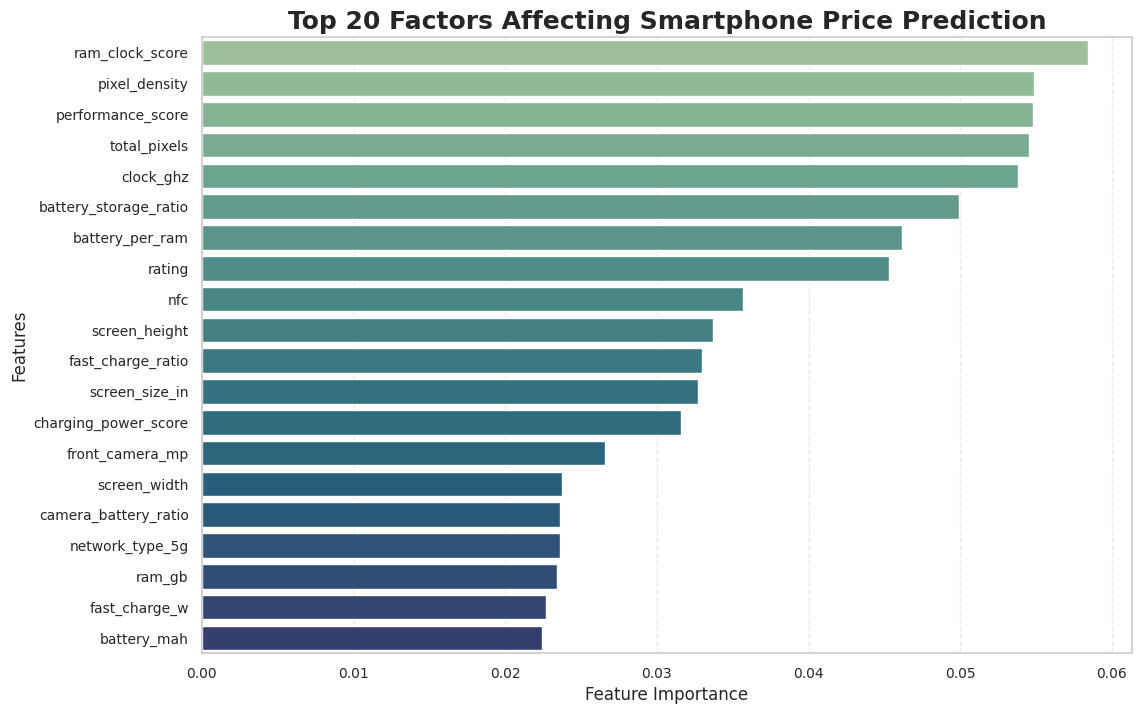

In [ ]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":
    rf_model.feature_importances_
})
importance.sort_values(
    "Importance",
    ascending=False
).head(20)
top_features = importance.sort_values(
    "Importance",
    ascending=False
).head(20)
plt.figure(figsize=(12,8))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="crest"
)
plt.title(
    "Top 20 Factors Affecting Smartphone Price Prediction",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel(
    "Feature Importance"
)
plt.ylabel(
    "Features"
)
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)
plt.show()

16. Evaluation of Optimized Model

In [ ]:
y_pred_best = best_model.predict(X_test)
print("Optimized Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

Optimized Decision Tree Accuracy:
0.8424657534246576

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        75
           1       0.68      0.82      0.74        39
           2       0.96      0.72      0.82        32

    accuracy                           0.84       146
   macro avg       0.85      0.82      0.82       146
weighted avg       0.86      0.84      0.84       146


Confusion Matrix:
[[68  7  0]
 [ 6 32  1]
 [ 1  8 23]]


17. Final Model Selection

In [ ]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": rf_model,
    "Optimized Decision Tree": best_model
}
accuracies = {
    "Logistic Regression": accuracy_score(y_test, y_pred_logistic),
    "Decision Tree": accuracy_score(y_test, y_pred_tree),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Optimized Decision Tree": accuracy_score(y_test, y_pred_best)
}
best_model_name = max(accuracies, key=accuracies.get)
print("Best Model:", best_model_name)
final_model = models[best_model_name]

Best Model: Optimized Decision Tree


18. Save the Model

In [ ]:
import joblib
joblib.dump(final_model, "smartphone_price_category_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

19. Model Prediction on New Data

In [ ]:
new_phone = pd.DataFrame({
    "rating": [88],
    "ram_gb": [12],
    "storage_gb": [256],
    "battery_mah": [5000],
    "fast_charge_w": [100],
    "clock_ghz": [3.2],
    "refresh_rate_hz": [120],
    "rear_camera_max_mp": [108],
    "rear_camera_count": [3],
    "front_camera_mp": [32],
    "screen_width": [1080],
    "screen_height": [2400],
    "screen_size_in": [6.7],

    "os": ["Android v14"],
    "network_type": ["5g"],
    "sim_type": ["Dual"],
    "volte": [True],
    "nfc": [True],
    "ir_blaster": [False],
    "chipset": ["Snapdragon 8 Gen 3"],
    "core_type": ["Octa Core"],
    "display_type": ["AMOLED"],
    "memory_card_supported": [False],
    "memory_card_type": ["None"]
})

new_phone["total_pixels"] = (
    new_phone["screen_width"] *
    new_phone["screen_height"]
)
new_phone["storage_ram_ratio"] = (
    new_phone["storage_gb"] /
    new_phone["ram_gb"]
)
new_phone["fast_charge_ratio"] = (
    new_phone["fast_charge_w"] /
    new_phone["battery_mah"]
)
new_phone["premium_display"] = (
    new_phone["refresh_rate_hz"] >= 120
).astype(int)
new_phone["battery_per_ram"] = (
    new_phone["battery_mah"] /
    new_phone["ram_gb"]
)
new_phone["camera_battery_ratio"] = (
    new_phone["rear_camera_max_mp"] /
    new_phone["battery_mah"]
)
new_phone["high_storage"] = (
    new_phone["storage_gb"] >= 256
).astype(int)
new_phone["high_ram"] = (
    new_phone["ram_gb"] >= 12
).astype(int)
new_phone["performance_score"] = (
    new_phone["ram_gb"] *
    new_phone["clock_ghz"]
)
new_phone["camera_score"] = (
    new_phone["rear_camera_count"] *
    new_phone["rear_camera_max_mp"]
)
new_phone["charging_power_score"] = (
    new_phone["fast_charge_w"] /
    new_phone["battery_mah"]
)

new_phone["pixel_density"] = (
    new_phone["total_pixels"] /
    (new_phone["screen_size_in"] ** 2)
)
new_phone["battery_storage_ratio"] = (
    new_phone["battery_mah"] /
    new_phone["storage_gb"]
)
new_phone["ram_clock_score"] = (
    new_phone["ram_gb"] *
    new_phone["clock_ghz"]
)
new_phone["camera_per_sensor"] = (
    new_phone["rear_camera_max_mp"] /
    new_phone["rear_camera_count"]
)
new_phone = new_phone[features]
new_phone = pd.get_dummies(new_phone)

new_phone = new_phone.reindex(
    columns=X.columns,
    fill_value=0
)

prediction = final_model.predict(new_phone)
prediction = label_encoder.inverse_transform(prediction)
print("Predicted Category:", prediction[0])

Predicted Category: Premium


**MODEL EVALUATION**

1. Import Required Evaluation Libraries

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
y_pred_final = final_model.predict(X_test)

2. Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred_final)
print("Accuracy:", accuracy)

Accuracy: 0.8424657534246576


3. Precision

In [ ]:
precision = precision_score(
    y_test,
    y_pred_final,
    average="weighted",
    zero_division=0
)

print("Precision:", precision)

Precision: 0.85767026134266


4. Recall

In [ ]:
recall = recall_score(
    y_test,
    y_pred_final,
    average="weighted",
    zero_division=0
)

print("Recall:", recall)

Recall: 0.8424657534246576


5. F1-Score

In [ ]:
f1 = f1_score(
    y_test,
    y_pred_final,
    average="weighted",
    zero_division=0
)

print("F1 Score:", f1)

F1 Score: 0.8445819869840258


6. Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred_final)
print(cm)

[[68  7  0]
 [ 6 32  1]
 [ 1  8 23]]


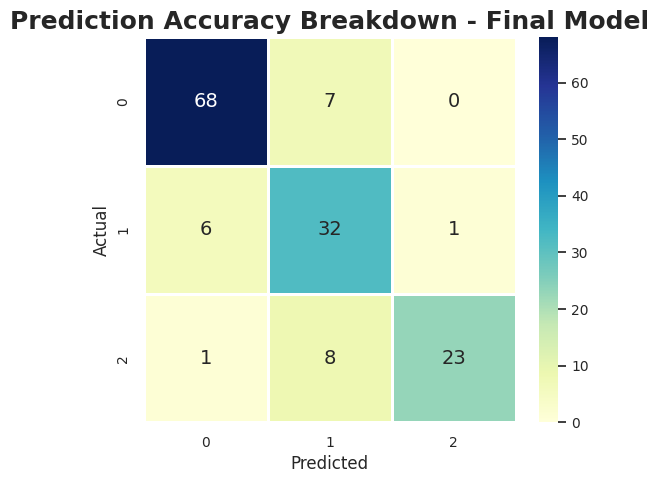

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white",
    annot_kws={"size":14}
)
plt.title(
    "Prediction Accuracy Breakdown - Final Model",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel(
    "Predicted"
)
plt.ylabel(
    "Actual"
)
plt.show()

7. Combined Evaluation Output

In [ ]:
print("=" * 40)
print("FINAL MODEL PERFORMANCE")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_final))
print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_final))

FINAL MODEL PERFORMANCE
Accuracy : 0.8425
Precision: 0.8577
Recall   : 0.8425
F1 Score : 0.8446

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        75
           1       0.68      0.82      0.74        39
           2       0.96      0.72      0.82        32

    accuracy                           0.84       146
   macro avg       0.85      0.82      0.82       146
weighted avg       0.86      0.84      0.84       146


Confusion Matrix

[[68  7  0]
 [ 6 32  1]
 [ 1  8 23]]


/tmp/ipykernel_616/1881878838.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  metric_plot = sns.barplot(


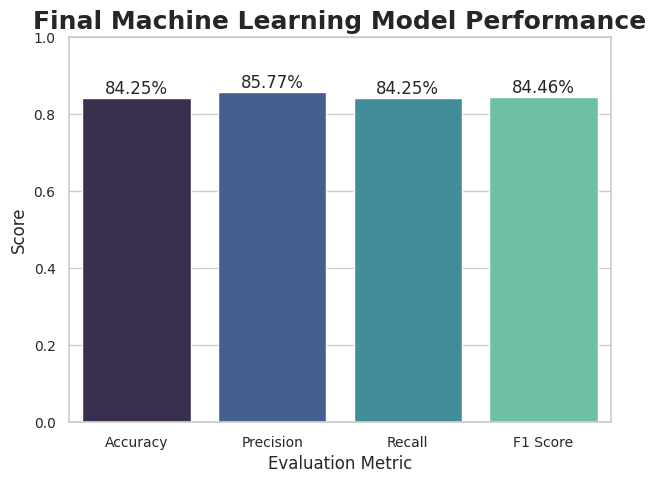

In [ ]:
metrics = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score":[
        accuracy,
        precision,
        recall,
        f1
    ]
})
plt.figure(figsize=(7,5))
metric_plot = sns.barplot(
    data=metrics,
    x="Metric",
    y="Score",
    palette="mako"
)
plt.title(
    "Final Machine Learning Model Performance",
    fontsize=18,
    fontweight="bold"
)
plt.ylim(
    0,
    1
)
for bar in metric_plot.patches:
    metric_plot.annotate(
        f"{bar.get_height():.2%}",
        (
            bar.get_x()+bar.get_width()/2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=12
    )
plt.ylabel(
    "Score"
)
plt.xlabel(
    "Evaluation Metric"
)
plt.show()